<a href="https://colab.research.google.com/github/azrasm/ml-hotel-booking-analysis/blob/main/Analiza_dataseta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prije čišćenja

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MU Projekat/hotel_bookings2(zaprljan).csv')

/tmp/ipython-input-3735005149.py:1: DtypeWarning: Columns (11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/MU Projekat/hotel_bookings2(zaprljan).csv')


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   hotel                           119390 non-null  object
 1   is_canceled                     119390 non-null  object
 2   lead_time                       119390 non-null  object
 3   arrival_date_year               119390 non-null  object
 4   arrival_date_month              119390 non-null  object
 5   arrival_date_week_number        119390 non-null  object
 6   arrival_date_day_of_month       119390 non-null  object
 7   stays_in_weekend_nights         119390 non-null  object
 8   stays_in_week_nights            119390 non-null  object
 9   adults                          119390 non-null  object
 10  children                        119386 non-null  object
 11  babies                          119390 non-null  object
 12  meal                          

In [ ]:
df.nunique()

,0
hotel,4
is_canceled,4
lead_time,479
arrival_date_year,3
arrival_date_month,24
arrival_date_week_number,53
arrival_date_day_of_month,578
stays_in_weekend_nights,17
stays_in_week_nights,35
adults,14


In [ ]:
from tabulate import tabulate

for column in df.columns:
    col_type = df[column].dtype  # Tip varijable
    if pd.api.types.is_numeric_dtype(df[column]):
        var_type = "Numerička"
        mean = df[column].mean()  # Srednja vrijednost
        median = df[column].median()  # Medijan
        min_val = df[column].min()  # Minimalna vrijednost
        max_val = df[column].max()  # Maksimalna vrijednost
        std_dev = df[column].std()  # Standardna devijacija
        most_frequent = None  # Nije primjenjivo za numeričke
        frequency = None
    else:
        var_type = "Kategorička"
        mean = None
        median = None
        min_val = None
        max_val = None
        std_dev = None
        most_frequent = df[column].mode().iloc[0] if not df[column].mode().empty else None
        frequency = df[column].value_counts().iloc[0] if most_frequent is not None else None

    missing_values = df[column].isna().sum()  # Broj nedostajućih vrijednosti

    if var_type == "Numerička":
        table_data = [
            ["Naziv varijable", column],
            ["Tip varijable", col_type],
            ["Numerička/Kategorička", var_type],
            ["Nedostajuće vrijednosti", missing_values],
            ["Srednja vrijednost", mean],
            ["Medijan", median],
            ["Minimalna vrijednost", min_val],
            ["Maksimalna vrijednost", max_val],
            ["Standardna devijacija", std_dev]
        ]
    else:
        table_data = [
            ["Naziv varijable", column],
            ["Tip varijable", col_type],
            ["Numerička/Kategorička", var_type],
            ["Nedostajuće vrijednosti", missing_values],
            ["Najveća frekvencija", most_frequent],
            ["Frekvencija", frequency]
        ]

    print(tabulate(table_data, headers="firstrow", tablefmt="pretty"))
    print("\n" + "-" * 50 + "\n")

+-------------------------+-------------+
|     Naziv varijable     |    hotel    |
+-------------------------+-------------+
|      Tip varijable      |   object    |
|  Numerička/Kategorička  | Kategorička |
| Nedostajuće vrijednosti |      0      |
|   Najveća frekvencija   | City Hotel  |
|       Frekvencija       |    51660    |
+-------------------------+-------------+

--------------------------------------------------

+-------------------------+-------------+
|     Naziv varijable     | is_canceled |
+-------------------------+-------------+
|      Tip varijable      |   object    |
|  Numerička/Kategorička  | Kategorička |
| Nedostajuće vrijednosti |      0      |
|   Najveća frekvencija   |      0      |
|       Frekvencija       |    36632    |
+-------------------------+-------------+

--------------------------------------------------

+-------------------------+-------------+
|     Naziv varijable     |  lead_time  |
+-------------------------+-------------+
|      Tip v

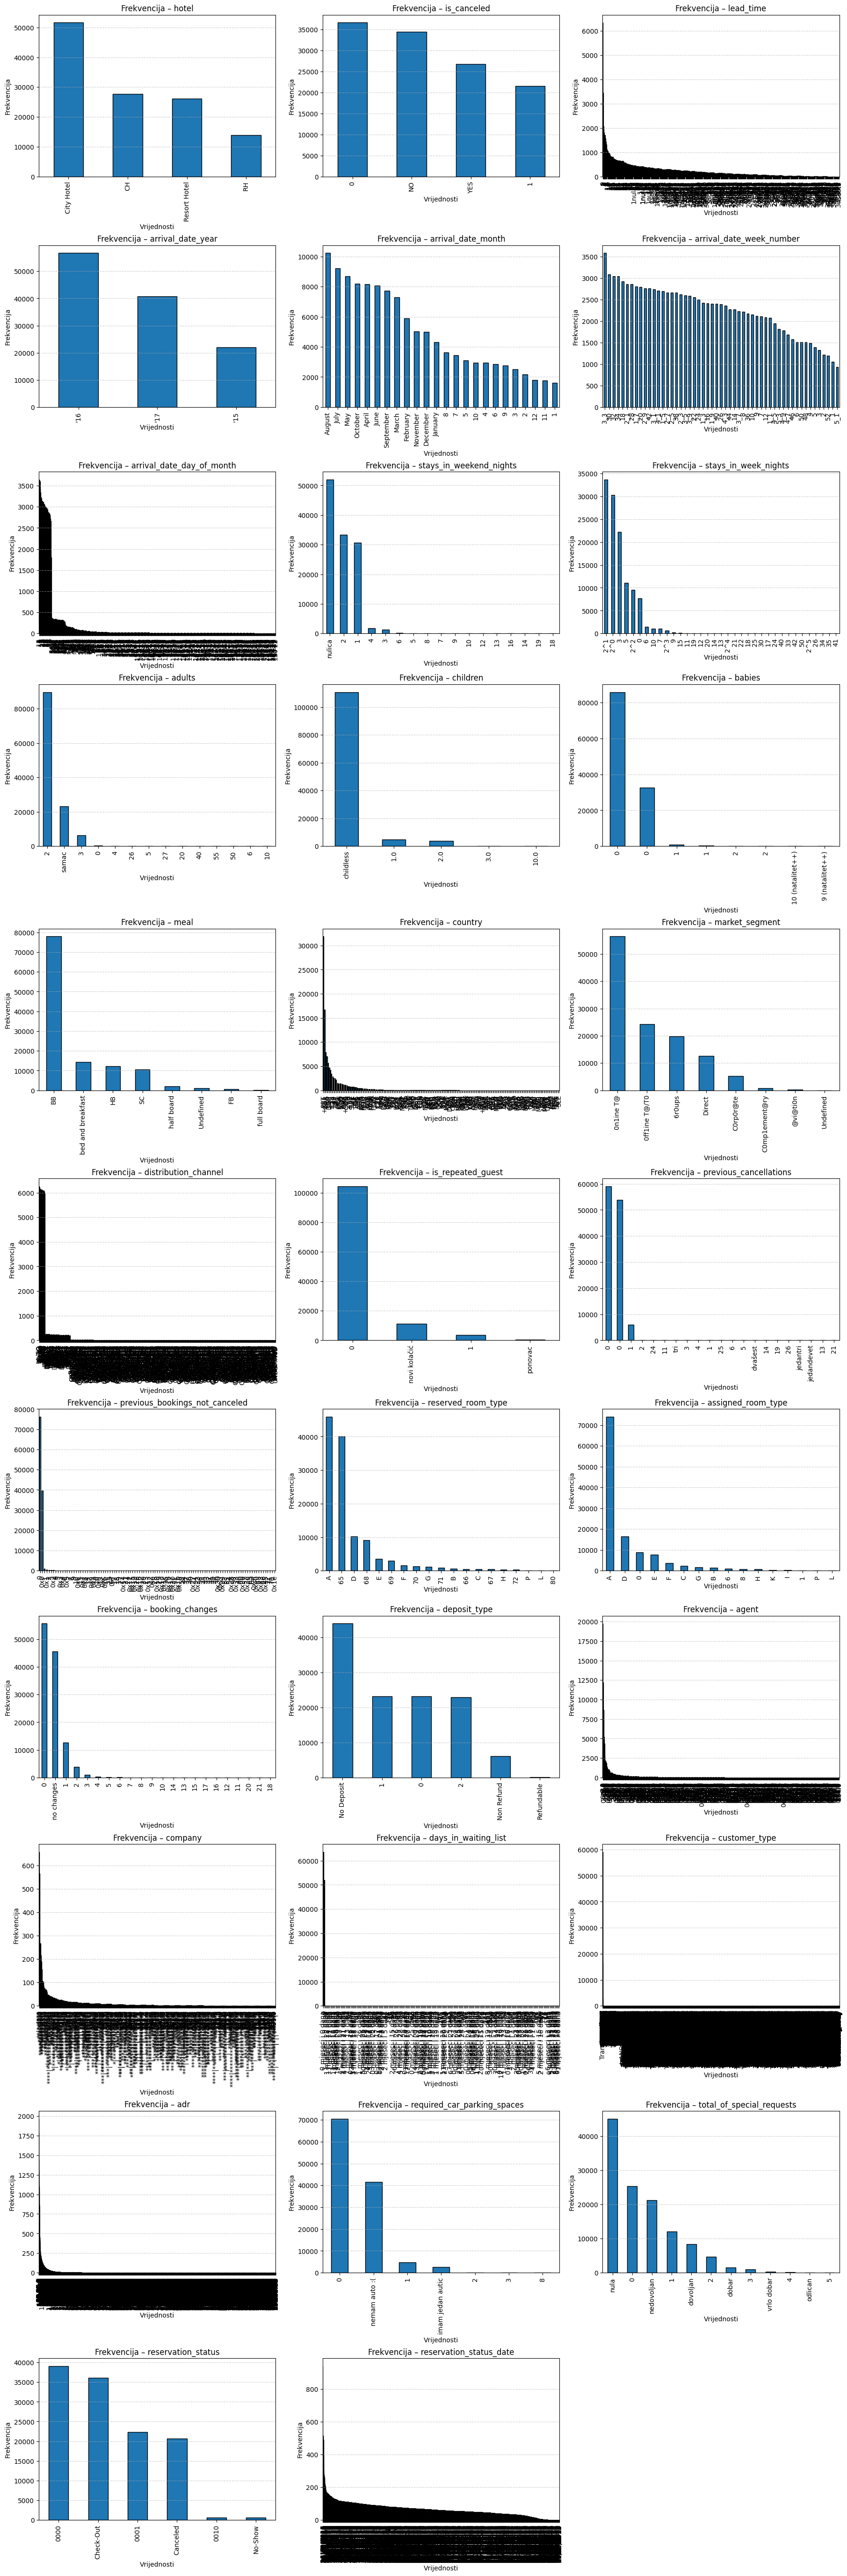

In [ ]:
import matplotlib.pyplot as plt

categorical_columns = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_columns) == 0:
    print("Nema kategorickih kolona za prikaz.")
else:
    num_columns = len(categorical_columns)
    num_cols = 3
    num_rows = (num_columns + num_cols - 1) // num_cols

    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(6 * num_cols, 5 * num_rows),
        constrained_layout=True
    )

    axes = axes.flatten()

    for ax, column in zip(axes, categorical_columns):
        value_counts = df[column].value_counts()

        value_counts.plot(
            kind='bar',
            ax=ax,
            edgecolor='black'
        )

        ax.set_title(f"Frekvencija – {column}", fontsize=12)
        ax.set_xlabel("Vrijednosti")
        ax.set_ylabel("Frekvencija")
        ax.tick_params(axis='x', rotation=90)
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    for ax in axes[len(categorical_columns):]:
        ax.set_visible(False)

    plt.show()

# Nakon čišćenja

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/MU Projekat/hotel_ociscen.csv')

In [ ]:
df2.shape

(119390, 30)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  int64  
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
numerical_columns = df2.select_dtypes(include=['number'])

correlation_matrix = numerical_columns.corr(method='pearson')

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        var_1 = correlation_matrix.columns[i]
        var_2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]
        print(f"Pearsonov koeficijent korelacije između varijabli {var_1} i {var_2} je {correlation_value:.2f}")


Pearsonov koeficijent korelacije između varijabli lead_time i is_canceled je 0.21
Pearsonov koeficijent korelacije između varijabli arrival_date_year i is_canceled je 0.01
Pearsonov koeficijent korelacije između varijabli arrival_date_year i lead_time je 0.04
Pearsonov koeficijent korelacije između varijabli arrival_date_week_number i is_canceled je 0.01
Pearsonov koeficijent korelacije između varijabli arrival_date_week_number i lead_time je 0.13
Pearsonov koeficijent korelacije između varijabli arrival_date_week_number i arrival_date_year je -0.54
Pearsonov koeficijent korelacije između varijabli arrival_date_day_of_month i is_canceled je -0.00
Pearsonov koeficijent korelacije između varijabli arrival_date_day_of_month i lead_time je 0.00
Pearsonov koeficijent korelacije između varijabli arrival_date_day_of_month i arrival_date_year je -0.00
Pearsonov koeficijent korelacije između varijabli arrival_date_day_of_month i arrival_date_week_number je 0.07
Pearsonov koeficijent korelacije 

In [ ]:
numerical_columns = df2.select_dtypes(include=['number'])

correlation_matrix = numerical_columns.corr(method='pearson')

print(correlation_matrix.to_string())

                                is_canceled  lead_time  arrival_date_year  arrival_date_week_number  arrival_date_day_of_month  stays_in_weekend_nights  stays_in_week_nights    adults  children    babies  is_repeated_guest  previous_cancellations  previous_bookings_not_canceled  booking_changes  days_in_waiting_list       adr  required_car_parking_spaces  total_of_special_requests
is_canceled                        1.000000   0.213383           0.011223                  0.005402                  -0.004015                -0.002911              0.018267  0.044228  0.004888 -0.025535          -0.058530                0.078423                       -0.040988        -0.104820              0.038495  0.034402                    -0.140093                  -0.171045
lead_time                          0.213383   1.000000           0.040142                  0.126871                   0.002268                 0.085671              0.165799  0.119519 -0.037613 -0.020915          -0.124410          

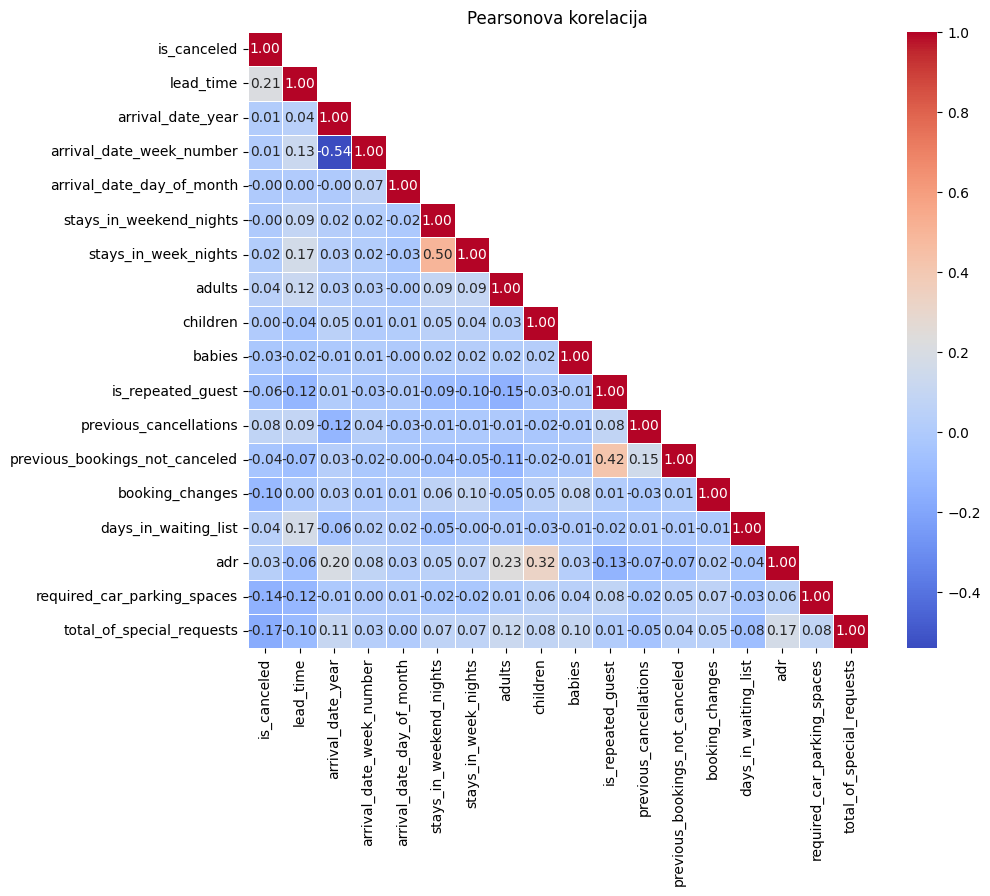

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

numeric_data = df2.select_dtypes(include=['number'])

#Računanje Pearsonovog koeficijenta korelacije za numeričke varijable
correlation_matrix = numeric_data.corr(method='pearson')

#Kreiranje maske za prikazivanje samo dijagonalnih vrijednosti i ispod dijagonale
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

#Kreiranje heatmap-a sa maskom
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', mask=mask, linewidths=0.5)

plt.title('Pearsonova korelacija')
plt.show()

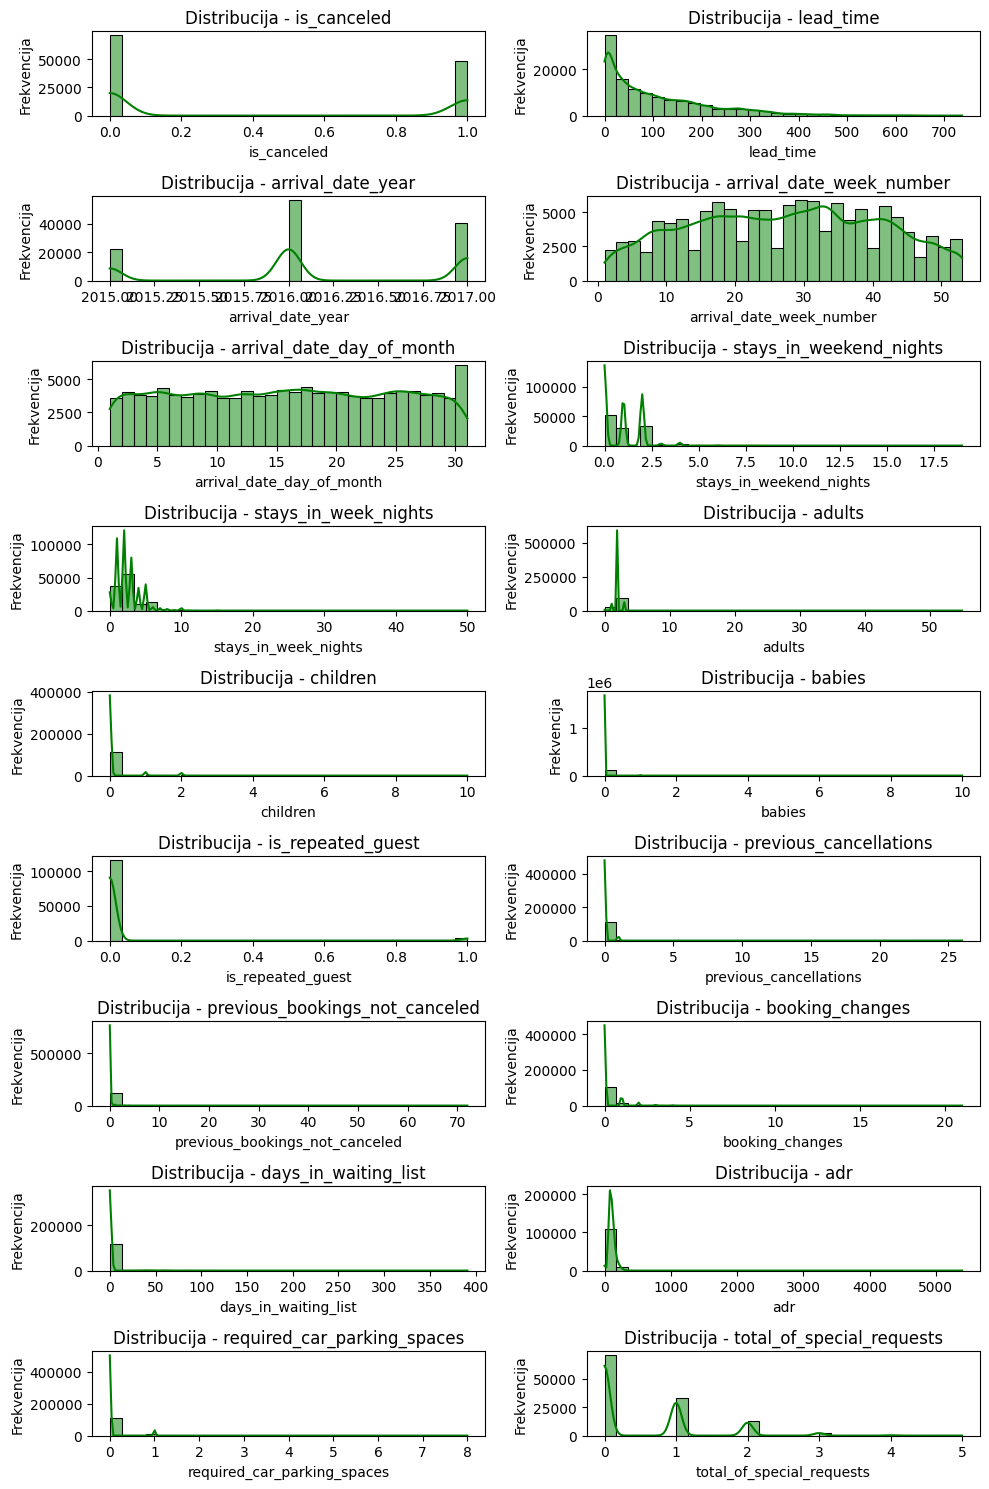

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_columns = df2.select_dtypes(include=['number'])

plt.figure(figsize=(10, 15))

num_columns = 2
num_rows = -(-len(numeric_columns.columns) // num_columns)

for i, column in enumerate(numeric_columns.columns, 1):
    plt.subplot(num_rows, num_columns, i)
    sns.histplot(df2[column], kde=True, bins=30, color='green')
    plt.title(f'Distribucija - {column}')
    plt.xlabel(column)
    plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

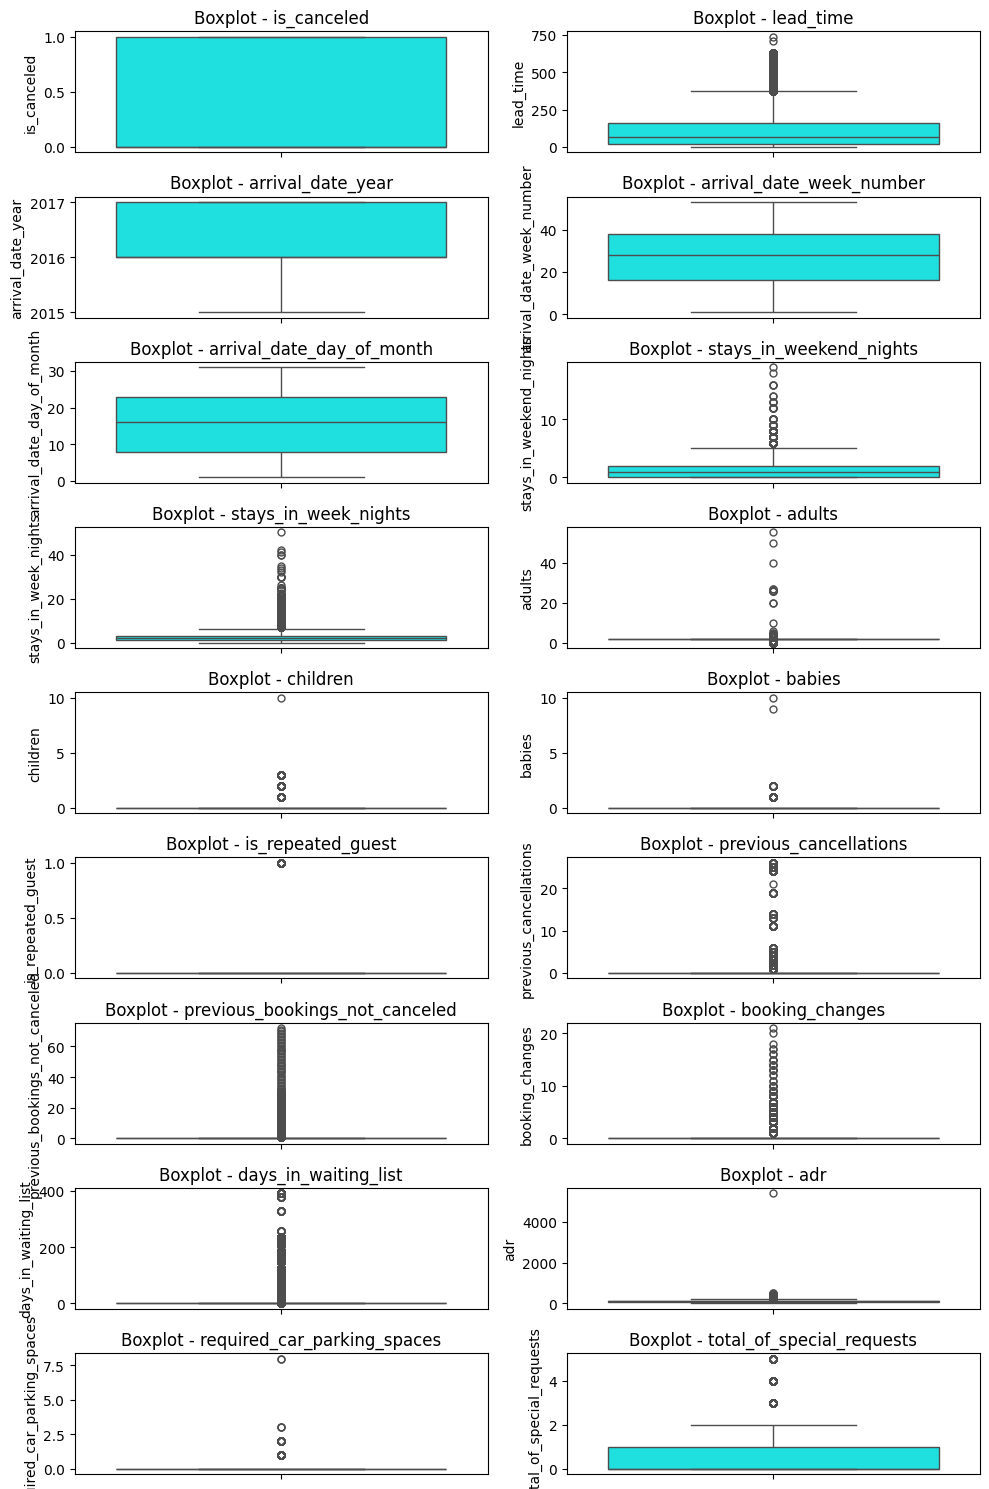

In [ ]:
numeric_columns = df2.select_dtypes(include=['number'])

plt.figure(figsize=(10, 15))

num_columns = 2
num_rows = -(-len(numeric_columns.columns) // num_columns)

for i, column in enumerate(numeric_columns.columns, 1):
    plt.subplot(num_rows, num_columns, i)
    sns.boxplot(data=df2, y=column, color='cyan', fliersize=5)
    plt.title(f'Boxplot - {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

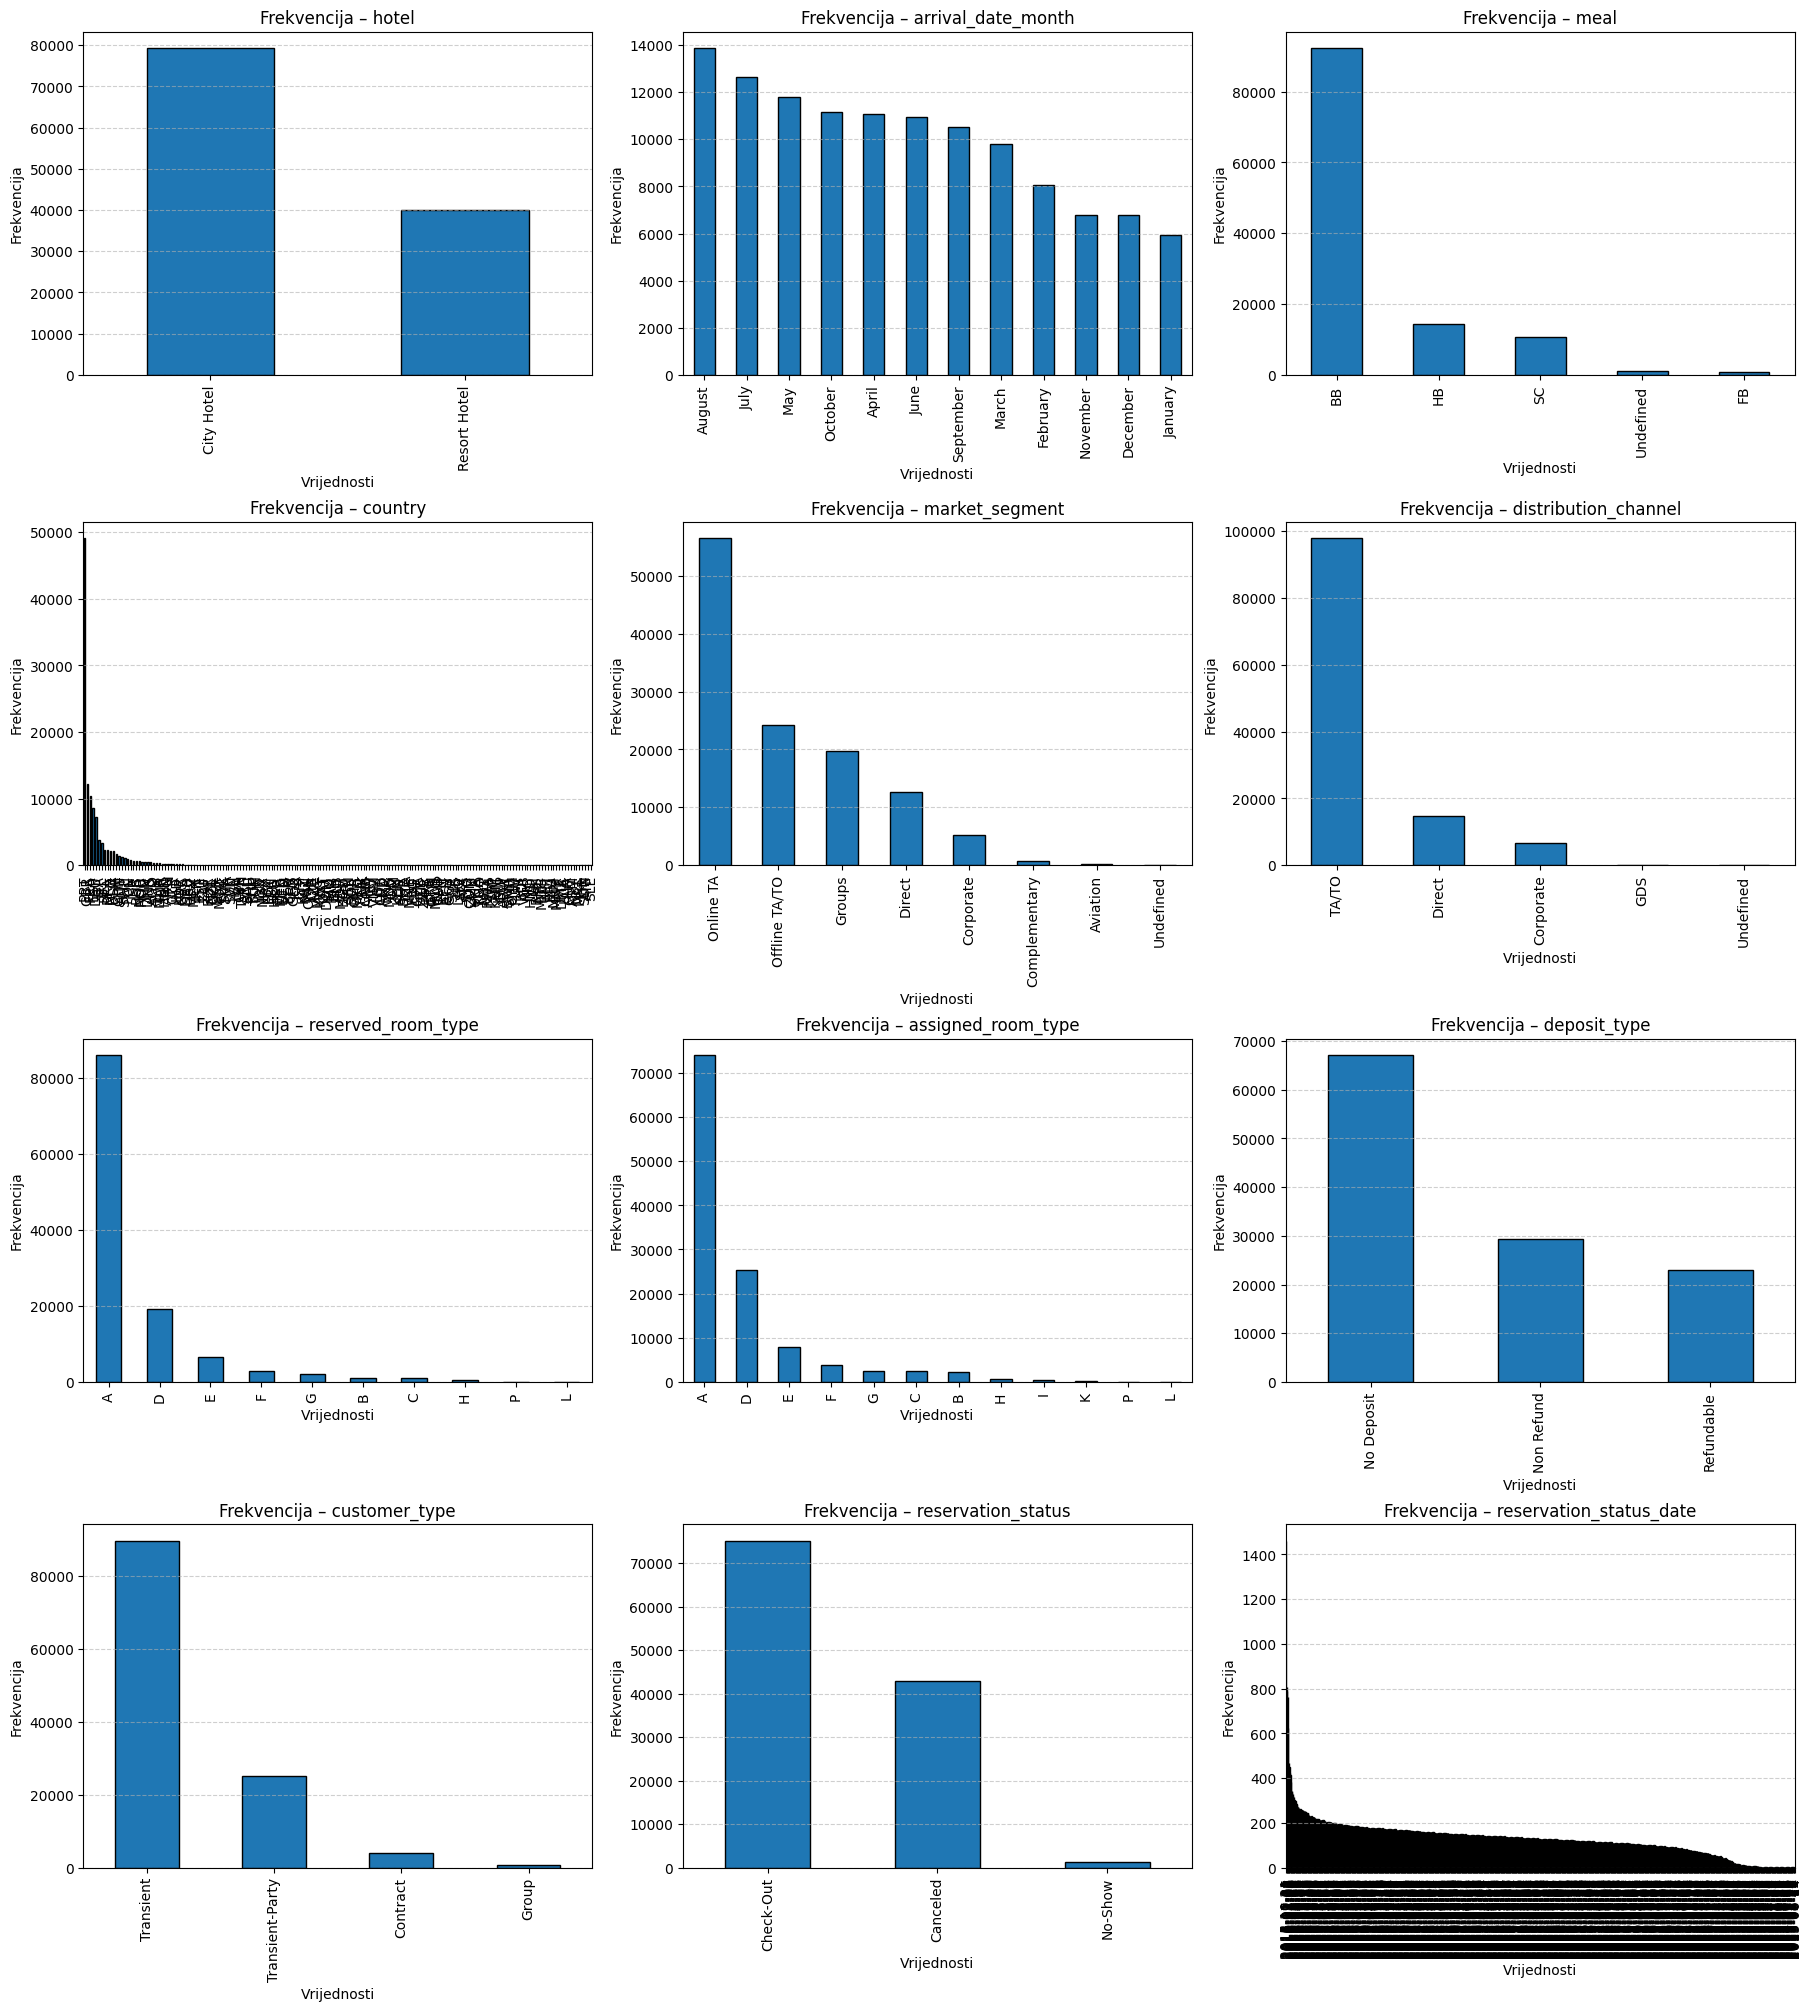

In [ ]:
categorical_columns = df2.select_dtypes(include=['object', 'category']).columns

if len(categorical_columns) == 0:
    print("Nema kategorickih kolona za prikaz.")
else:
    num_columns = len(categorical_columns)
    num_cols = 3
    num_rows = (num_columns + num_cols - 1) // num_cols

    fig, axes = plt.subplots(
        nrows=num_rows,
        ncols=num_cols,
        figsize=(6 * num_cols, 5 * num_rows),
        constrained_layout=True
    )

    axes = axes.flatten()

    for ax, column in zip(axes, categorical_columns):
        value_counts = df2[column].value_counts()

        value_counts.plot(
            kind='bar',
            ax=ax,
            edgecolor='black'
        )

        ax.set_title(f"Frekvencija – {column}", fontsize=12)
        ax.set_xlabel("Vrijednosti")
        ax.set_ylabel("Frekvencija")
        ax.tick_params(axis='x', rotation=90)
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    for ax in axes[len(categorical_columns):]:
        ax.set_visible(False)

    plt.show()